In [1]:
# !pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
def wrangle(path, col_1, col_2):

    # Import data
    df = pd.read_csv(path)

    # Datetime 
    df[col_1] = pd.to_datetime(df[col_1])

    # Rename the column to date
    df.rename(columns={col_1: 'Date'}, inplace=True)

    # Replace missing values
    df[col_2] = df[col_2].replace('.', pd.NA)
    # Convert to numeric, coercing errors to NaN
    df[col_2] = pd.to_numeric(df[col_2], errors='coerce')
    # Handle NaN values
    df.dropna(subset=[col_2], inplace=True)  # Drop rows with NaN

    # Only select data after 2000
    df = df[df['Date'] >= '2000-01-01']

    df = df.set_index('Date')

    return df

In [4]:
vix = wrangle("/Users/alexzheng/Library/Mobile Documents/com~apple~CloudDocs/[03] School/[01] Warwick/[02] Year 3/EC331 Project/data/CBOE_Volatility_Index.csv",
        "DATE",
        "VIXCLS")
vix

,VIXCLS
Date,
2000-01-03,24.21
2000-01-04,27.01
2000-01-05,26.41
2000-01-06,25.73
2000-01-07,21.72
...,...
2024-11-14,14.31
2024-11-15,16.14
2024-11-18,15.58


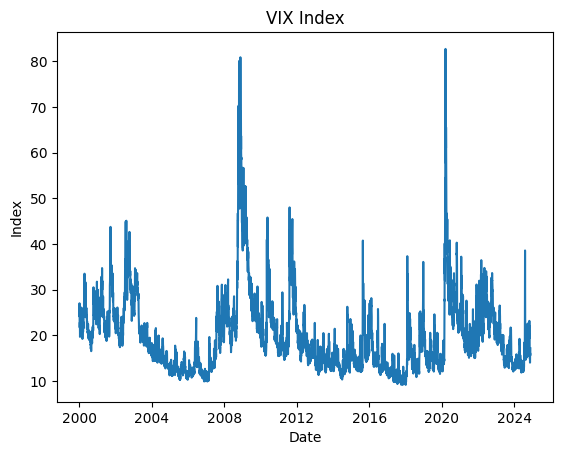

In [5]:
plt.plot(vix.index, vix['VIXCLS'])
plt.xlabel('Date')
plt.ylabel('Index')
plt.title("VIX Index");

In [6]:
JPY_exchange_rate_per_USD = wrangle("/Users/alexzheng/Library/Mobile Documents/com~apple~CloudDocs/[03] School/[01] Warwick/[02] Year 3/EC331 Project/data/Japanese_Yen_to_US_Dollar_Spot_Exchange_Rate.csv",
                                    "DATE",
                                    "DEXJPUS")
JPY_exchange_rate_per_USD

,DEXJPUS
Date,
2000-01-03,101.70
2000-01-04,103.09
2000-01-05,103.77
2000-01-06,105.19
2000-01-07,105.17
...,...
2024-11-08,152.58
2024-11-12,154.73
2024-11-13,155.28


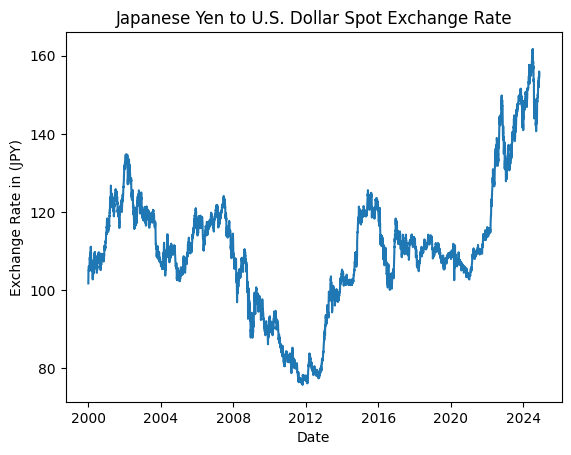

In [7]:
plt.plot(JPY_exchange_rate_per_USD.index, JPY_exchange_rate_per_USD['DEXJPUS'])
plt.xlabel('Date')
plt.ylabel('Exchange Rate in (JPY)')
plt.title("Japanese Yen to U.S. Dollar Spot Exchange Rate");

In [8]:
Japan_IR = wrangle("/Users/alexzheng/Library/Mobile Documents/com~apple~CloudDocs/[03] School/[01] Warwick/[02] Year 3/EC331 Project/data/Japan_Government_Debt_10_Year.csv",
                                        "Pricing Date",
                                        "Japan Government Debt - 10 Year")

Japan_IR

,Japan Government Debt - 10 Year
Date,
2000-01-01,1.600
2000-01-02,1.600
2000-01-03,1.600
2000-01-04,1.660
2000-01-05,1.640
...,...
2024-11-13,1.039
2024-11-14,1.054
2024-11-15,1.070


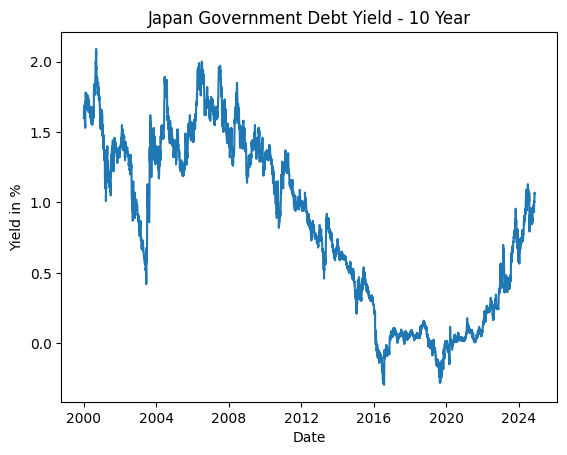

In [9]:
plt.plot(Japan_IR.index, Japan_IR['Japan Government Debt - 10 Year'])
plt.xlabel('Date')
plt.ylabel('Yield in %')
plt.title("Japan Government Debt Yield - 10 Year");

In [10]:
US_IR = wrangle("/Users/alexzheng/Library/Mobile Documents/com~apple~CloudDocs/[03] School/[01] Warwick/[02] Year 3/EC331 Project/data/Market_Yield_US_Treasury_Securities_10_Year_Constant_Maturity_Investment_Basis.csv",
                "DATE",
                "DGS10")
US_IR

,DGS10
Date,
2000-01-03,6.58
2000-01-04,6.49
2000-01-05,6.62
2000-01-06,6.57
2000-01-07,6.52
...,...
2024-11-12,4.43
2024-11-13,4.44
2024-11-14,4.43


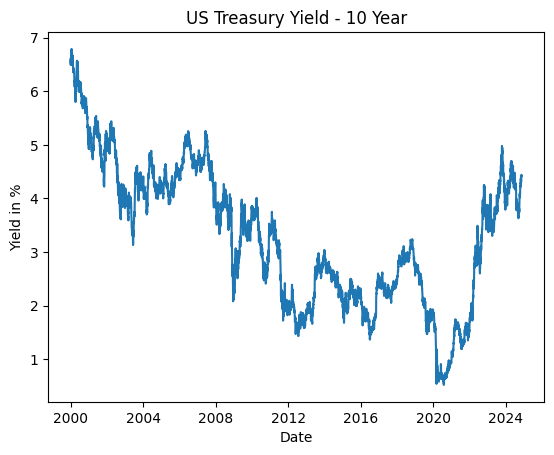

In [11]:
plt.plot(US_IR.index, US_IR['DGS10'])
plt.xlabel('Date')
plt.ylabel('Yield in %')
plt.title("US Treasury Yield - 10 Year");